### Logistic Regression

- used to solve classification problems
- It's Binary classification

In [1]:
import pandas as pd

data = {
    "age": [
        22, 25, 47, 52, 46, 56, 55, 60, 62, 61,
        18, 28, 27, 29, 49,23,67,56,43,12,66,11,32,87,45,75
    ],
    "have_insurance": [
        0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
        0, 0, 0, 0, 1,1,1,1,1,0,1,1,0,0,1,1
    ]
}

df = pd.DataFrame(data)
print(df)


    age  have_insurance
0    22               0
1    25               0
2    47               1
3    52               0
4    46               1
5    56               1
6    55               0
7    60               1
8    62               1
9    61               1
10   18               0
11   28               0
12   27               0
13   29               0
14   49               1
15   23               1
16   67               1
17   56               1
18   43               1
19   12               0
20   66               1
21   11               1
22   32               0
23   87               0
24   45               1
25   75               1


The graph should be linearly seperable

To find the equation of the line, we use:

The general equation of a straight line

$$
Ax_1 + Bx_2 + C = 0
$$

The linear combination (logit) is:

$$
z = w_1 x_1 + w_2 x_2 + w_0
$$


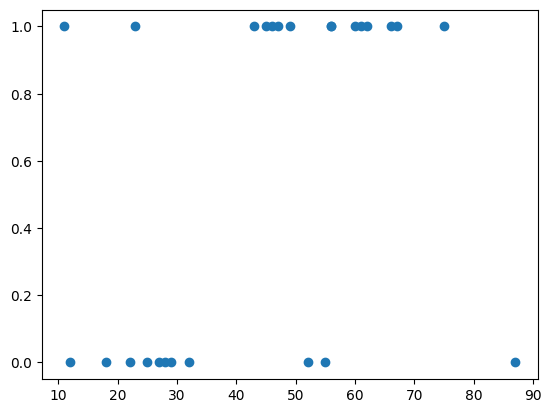

In [2]:
import matplotlib.pyplot as plt
plt.scatter(df['age'],df['have_insurance'])

there are some outliers in this dataset 
to deal with that we need sigmoid function

#### <u>The sigmoid function</u>

$$
\text{sigmoid}(z) = \frac{1}{1 + e^{-z}}
$$

Where:

- $e$ = Euler's number $\approx 2.71828$

even if the value of z varies between -inf to inf , y value will be in btn -1 and 1

##### Step 1: Linear score (logit)
$$
z = \sum_{i=1}^{n} w_i x_i
$$

Linear score(logit) is the raw output of the linear equation before applying sigmoid

Logits are used before the sigmoid because probabilities (0–1) are hard to model linearly, but log-odds are easy to model linearly.

- it turns probability into a straght line 
- Features → Linear score (logit) → Sigmoid → Probability → Class
- The logit equation is:

$$
\ln\left(\frac{p}{1 - p}\right)
= z
= w_1 x_1 + w_2 x_2 + \cdots + b
$$

Where:

- $p$ : Predicted probability that the output belongs to class 1  
- $1 - p$ : Probability that the output belongs to class 0  
- $\ln$ : Natural logarithm  
- $\ln\left(\frac{p}{1 - p}\right)$ : Logit (log-odds)  
- $z$ : Linear score (logit value before sigmoid)  
- $w_1, w_2, \ldots$ : Model weights (coefficients)  
- $x_1, x_2, \ldots$ : Input feature values  
- $b$ : Bias (intercept) term  



---

##### Step 2: Convert to probability (Sigmoid function)

Sigmoid is used to convert the logit output into probabilities, and these probabilities are used to compute the loss, whose gradient is then used to update the feature weights.

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

---

##### Step 3: Compare with actual label
$$
\text{error} = y - \hat{y}
$$

This alone is not enough to train a model: 

##### LOSS FUNCTION
A loss function converts error into a single positive number that:

- Quantifies how bad the prediction is

- Is smooth & differentiable

- Can guide weight updates

##### Binary Cross Entropy Loss:

Cross-entropy loss punishes confident wrong predictions very heavily and rewards confident correct ones.

It measures the distance between the true distribution and predicted distribution.

The loss function (Binary Cross-Entropy) is:

$$
\text{Loss}
= - \left[
y \log(\hat{y})
+ (1 - y)\log(1 - \hat{y})
\right]
$$

---

##### Step 4: Update weight
$$
w_i = w_i + \eta (y - \hat{y}) x_i
$$

Inputs → Linear sum → Sigmoid → Probability
                ↓
            Error
                ↓
         Weight update

What changes?
- The weights are slightly different
- This changes the linear score (logit) for the same input
- Which changes the probability next time
👉 The model has learned a little from its mistake.



The Softmax function is:

$$
P_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

Where:

- $P_i$ : Probability of class $i$  
- $z_i$ : Score (logit) for class $i$  
- $K$ : Total number of classes  
- $e$ : Euler's number ($\approx 2.71828$)



| Scenario                       | Function Used | Purpose                   |
| ------------------------------ | ------------- | ------------------------- |
| Binary Logistic Regression     | **Sigmoid**   | Probability of class 1    |
| Multiclass Logistic Regression | **Softmax**   | Probability of each class |


In [3]:
df.shape

(26, 2)

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
x_train,x_test,y_train,y_test=train_test_split(df[['age']],df['have_insurance'],train_size=0.9)

In [6]:
len(x_train)

23

In [7]:
from sklearn.linear_model import LogisticRegression

In [8]:
model=LogisticRegression()

In [9]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
x_test

,age
11,28
20,66
23,87


In [11]:
model.predict(x_test)

array([0, 1, 1])

In [12]:
model.score(x_test,y_test)

0.6666666666666666

In [13]:
model.predict_proba(x_test)

array([[0.61338766, 0.38661234],
       [0.08769249, 0.91230751],
       [0.02000505, 0.97999495]])

In [14]:
model.predict([[25]])

d:\Data_Science\data-science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [15]:
y_pred=model.predict(x_test)

In [16]:
from sklearn.metrics import confusion_matrix,classification_report

In [17]:
cm=confusion_matrix(y_test,y_pred)

<Axes: >

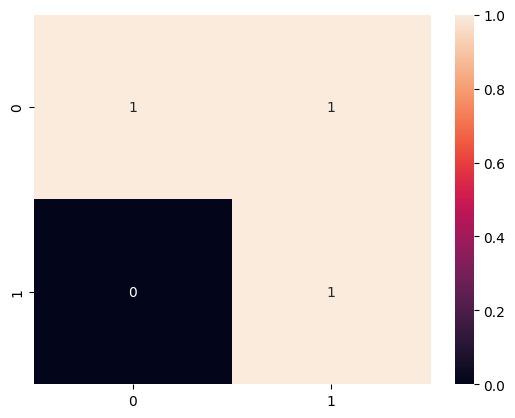

In [18]:
import seaborn as sns
sns.heatmap(cm,annot=True)

In [19]:
import seaborn as sns
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression



In [21]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [22]:
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']]

In [23]:
df['age'].fillna(df['age'].mean(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)


C:\Users\Admin\AppData\Local\Temp\ipykernel_9536\566924755.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_9536\566924755.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [24]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])


In [25]:
X = df.drop('survived', axis=1)
y = df['survived']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [28]:
model = LogisticRegression()
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
y_pred = model.predict(X_test)


In [30]:
from sklearn.metrics import classification_report,confusion_matrix

In [31]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [32]:
cm=confusion_matrix(y_test,y_pred)

<Axes: >

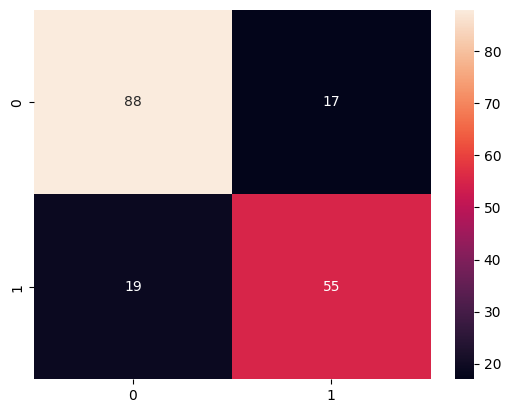

In [33]:
sns.heatmap(cm,annot=True)